<a href="https://colab.research.google.com/github/THEWACHER1103/Analisis_SuperStore/blob/main/prueba_CHURN_ipynb_2_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Churn - Retención de Clientes

La retención de clientes es un factor clave en la rentabilidad de cualquier empresa, ya que el costo de adquisición de nuevos clientes suele ser significativamente mayor que el de mantener los existentes.

En este proyecto se desarrolla un modelo de machine learning orientado a predecir la probabilidad de churn (abandono del cliente).


## Descripcion de Variables.
Variable objetivo:

* 1 = Churn (Cliente con posibilidad de abandono)
* 0 = No Churn (Cliente retenido)

* gender = Género del cliente (Male / Female)

* SeniorCitizen = Indica si el cliente es adulto mayor (1 = Sí, 0 = No)

* Partner = Si el cliente tiene pareja (Yes / No)

* Dependents = Si el cliente tiene dependientes (Yes / No)

* tenure = Tiempo (en meses) que el cliente lleva con la empresa.

* PhoneService = Si tiene servicio telefónico

* MultipleLines = Si tiene múltiples líneas telefónicas

* InternetService = Tipo de servicio de internet (DSL/Fiber optic /No)

* OnlineSecurity = Seguridad en línea

* OnlineBackup = Respaldo en la nube

* DeviceProtection = Protección de dispositivos

* TechSupport = Soporte técnico

* StreamingTV = Servicio de TV

* StreamingMovies = Servicio de películas

* Contract = Tipo de contrato. (Month-to-month /One year /Two year)

* PaperlessBilling = Facturación digital.

* PaymentMethod =Método de pago. (Electronic check / Mailed check / Bank transfer / Credit card)

* MonthlyCharges = Cargo mensual del cliente

* TotalCharges = Total pagado por el cliente



* Las variables incluyen características demográficas, servicios contratados, tipo de contrato y comportamiento de facturación, lo que permite analizar el churn desde múltiples dimensiones: comportamiento del cliente, nivel de engagement y factores económicos.

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import make_scorer
from sklearn.utils import shuffle
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score,log_loss, make_scorer
!pip install category_encoders
from category_encoders import TargetEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
pd.set_option('display.max_columns', None)
from category_encoders import WOEEncoder
from sklearn import set_config
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
!pip install optuna
import optuna
#set_config(transform_output="pandas")

In [7]:
df = pd.read_csv('train.csv')
df.drop(columns='id', inplace=True)
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [8]:
print(f"{df.info()}")
print('*=' * 30)
print(f"{df.isna().sum()}")
print('\n *=' * 30)
print(f"{df.isnull().sum()}")
print('*='*30)
print(f"{df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

* En el DataSet no existen Null's y ni Nan, tenemos muchas variables discretas no numericas las mismas requeriran transformacion, algunas binarias.

## Análisis Exploratorio de Datos (EDA)

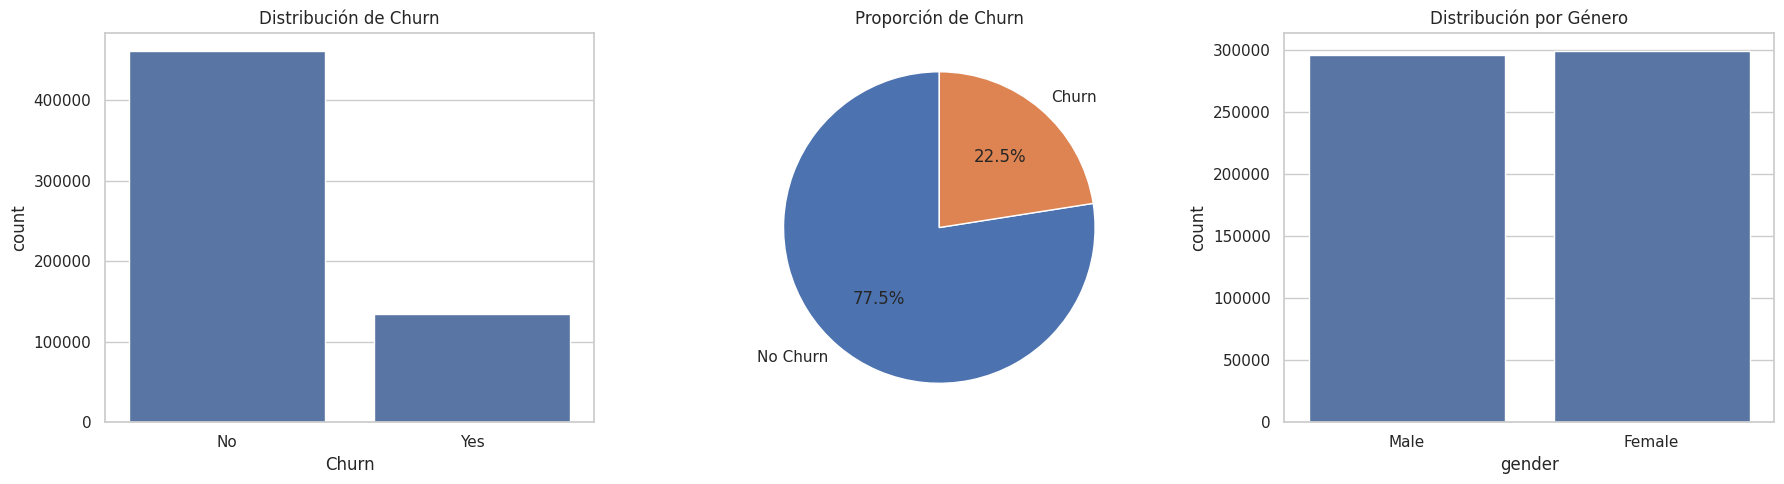

Churn
No     460377
Yes    133817
Name: count, dtype: int64
******************************
gender
Female    50.276172
Male      49.723828
Name: proportion, dtype: float64


In [9]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Churn
sns.countplot(x='Churn', data=df, ax=axes[0])
axes[0].set_title('Distribución de Churn')


# Pie Chart (Churn)
churn_counts = df['Churn'].value_counts()
axes[1].pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proporción de Churn')


# Género

sns.countplot(x='gender', data=df, ax=axes[2])
#axes[2].set_yscale('log')
axes[2].set_title('Distribución por Género')

# Ajustar espacios
plt.tight_layout()
plt.show()

print(df['Churn'].value_counts())
print('**'*15)
print(df['gender'].value_counts(normalize=True)*100)

* El dataset presenta desbalance (22.5% churn vs 77.5% no churn), lo cual deberá considerarse en el modelado.

## Describe

In [10]:
def describe_modif(df):
    num_df = df.select_dtypes(include='number')
    desc = num_df.describe()
    desc.loc['count ceros'] = (num_df == 0).sum()
    desc.loc['count negativos'] = (num_df < 0).sum()
    desc.loc['count null'] = num_df.isna().sum()
    desc.loc['pct ceros'] = (num_df == 0).mean()
    desc.loc['pct negativos'] = (num_df < 0).mean()
    desc.loc['pct nulls'] = num_df.isna().mean()
    desc.loc['Coef. Variacion'] = desc.loc['std'] / desc.loc['mean']
    q1 = desc.loc['25%']
    q3 = desc.loc['75%']
    iqr = q3 - q1
    desc.loc['IQR'] = iqr
    outliers = ((num_df < (q1 - 1.5 * iqr))|(num_df > (q3 + 1.5 * iqr))).sum()
    desc.loc['Conteo de Outliers'] = outliers
    desc.loc['Asimetria'] = num_df.skew()
    percentiles = [0, 0.25,0.50, 0.75, 0.90,0.97, 0.98, 0.99,1]
    for p in percentiles:
        desc.loc[f'P{int(p*100)}'] = num_df.quantile(p)
    desc = desc.drop(index=['min','25%','50%','75%', 'max'])
    return desc.round(2)

describe_modif(df)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.00,594194.00,594194.00,594194.00
mean,0.11,36.58,65.87,2494.38
std,0.32,25.06,31.07,2353.92
count ceros,526395.00,0.00,0.00,0.00
count negativos,0.00,0.00,0.00,0.00
count null,0.00,0.00,0.00,0.00
pct ceros,0.89,0.00,0.00,0.00
pct negativos,0.00,0.00,0.00,0.00
pct nulls,0.00,0.00,0.00,0.00
Coef. Variacion,2.79,0.69,0.47,0.94


# Distribucion de Variables Numericas.

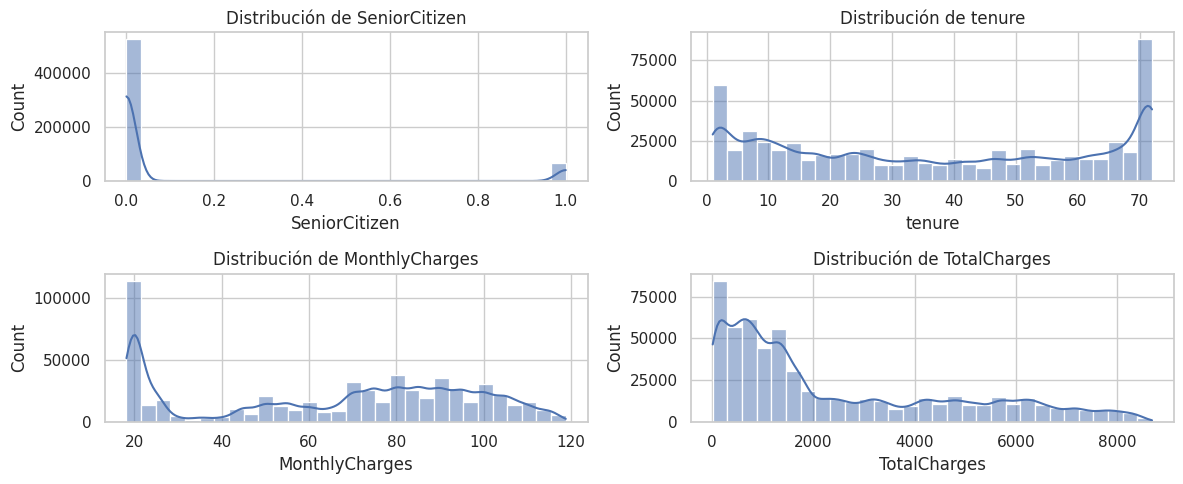

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12,5))

numerical_col = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']

for i, col in enumerate(numerical_col):
    row = i // 2
    col_idx = i % 2

    sns.histplot(df[col], bins=30, kde=True, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

# Observaciones Variables Numericas:

* La variable **SeniorCitizen** es una variable binaria, la cual indica que tenemos una poblacion en su mayoria joven.

* En **MonthlyCharges** confirmo la presencia de algunos bayes y Outliers, podria monstrar algun patron de subcripciones aumento de subscripciones en meses especificos.

* En **TotalCharges** se muestra una grafica decreciente con una fuerte concentracion de 0 a 1900 USD, cabe destacar que esta variable es medida en USD, tambien podria indicar que algunos clientes se atrasan levemente.

* En **Ternure** confirmo la existencia de Outliers los mismos indican una retencion balanceada por clientes viejos mostrando clientes que tienen mas de 70 meses con el servicio contratado, pero tambien muestra una gran masa de clientes que son nuevos y se tendria que buscar los puntos fuertes para hacer que duren en el tiempo.

# Distribucion de Variables Categoricas.

In [12]:
categorical_cols= df.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ["Churn", "gender"]]

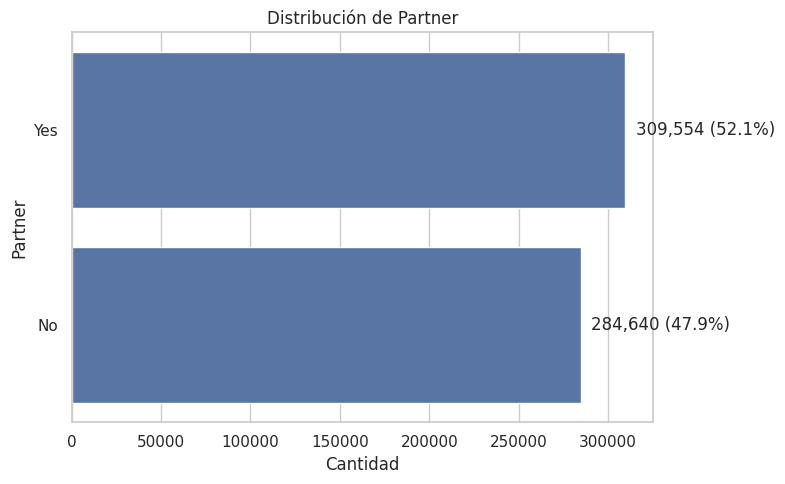

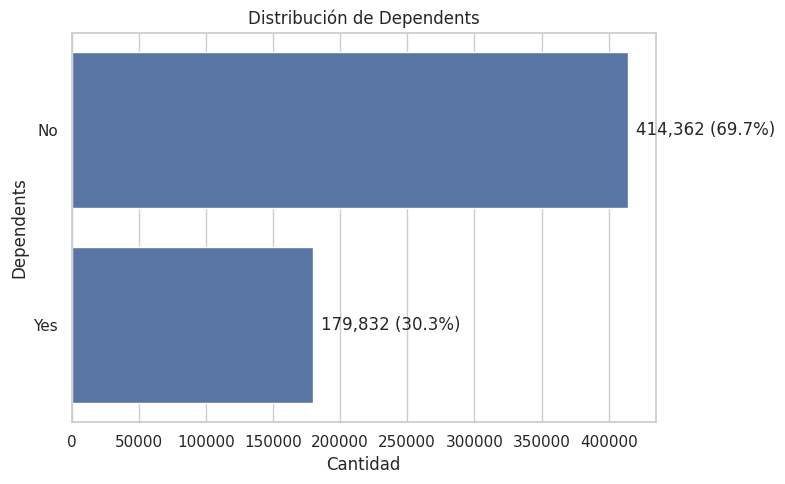

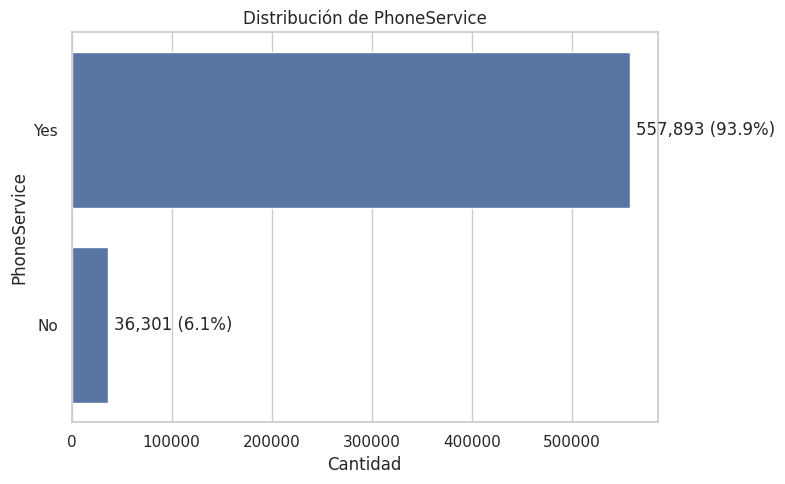

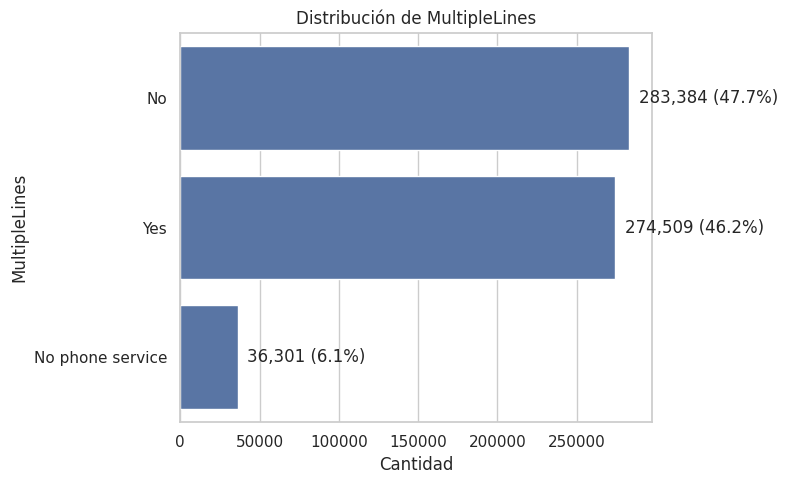

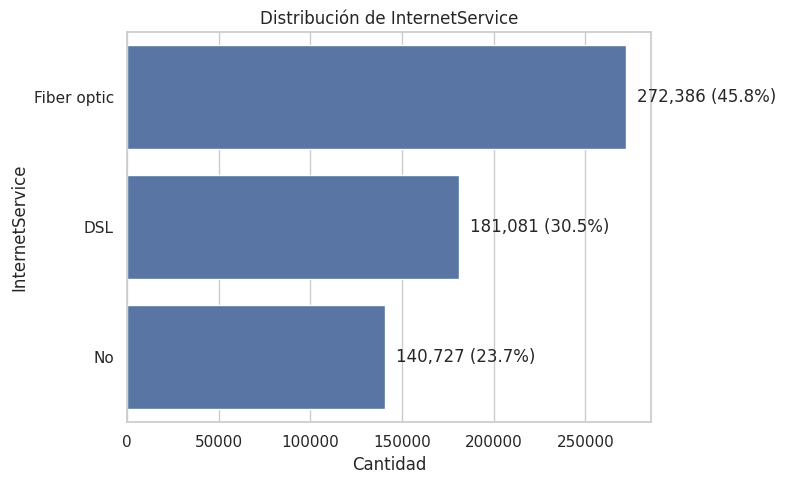

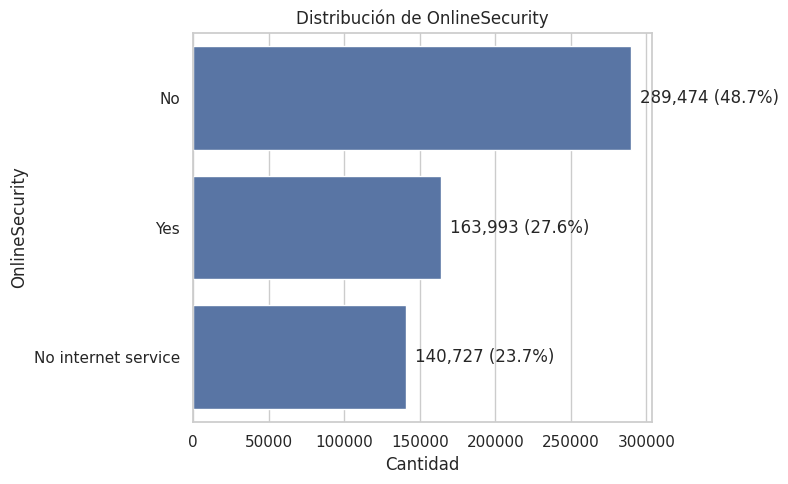

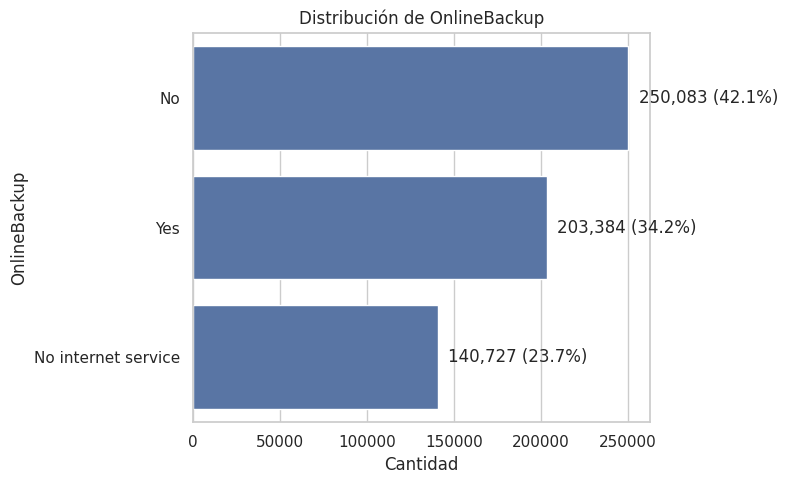

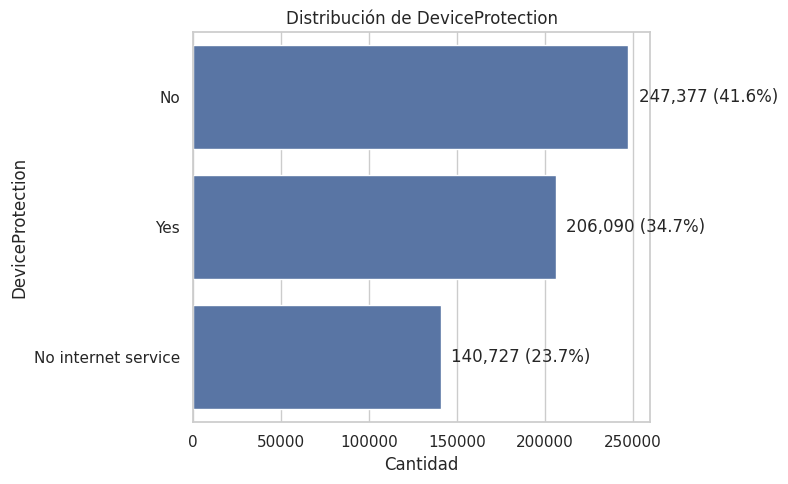

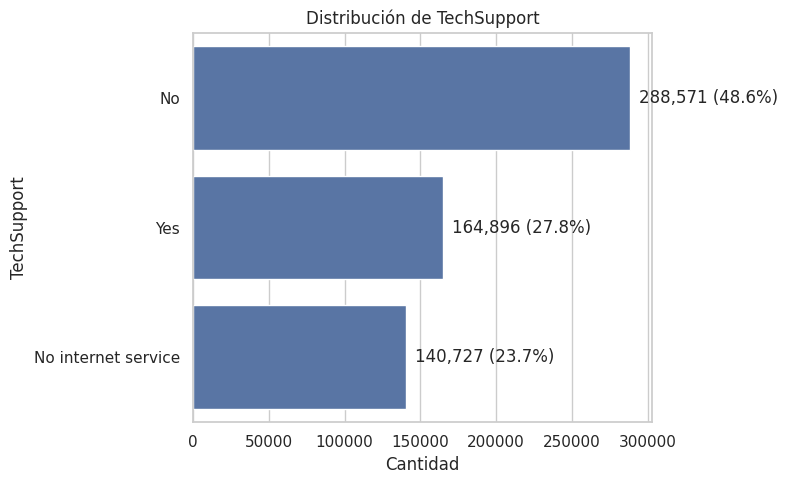

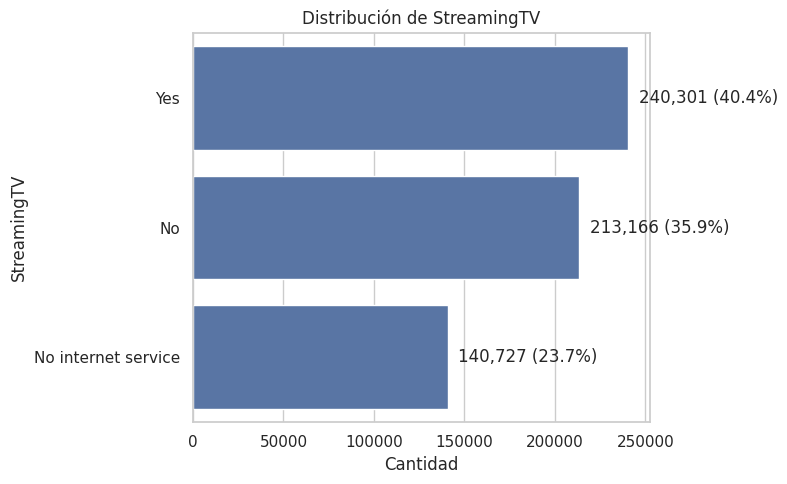

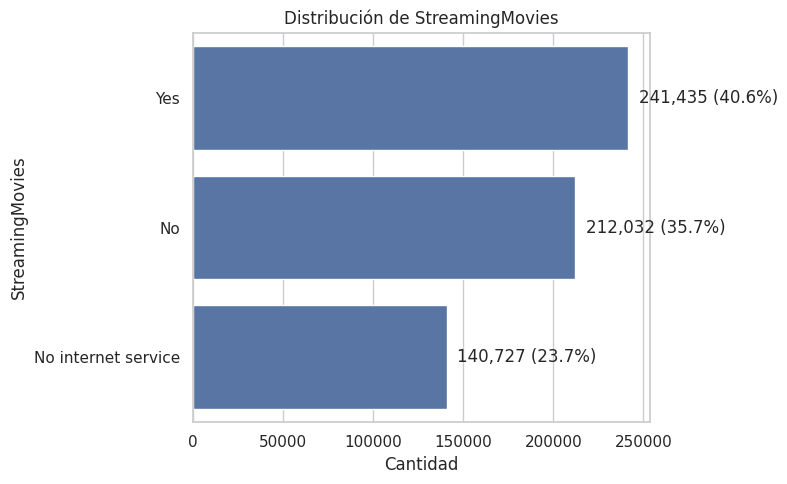

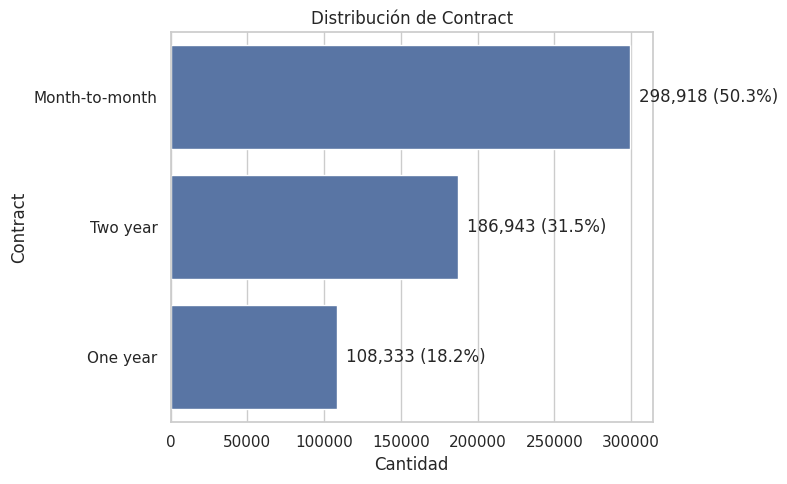

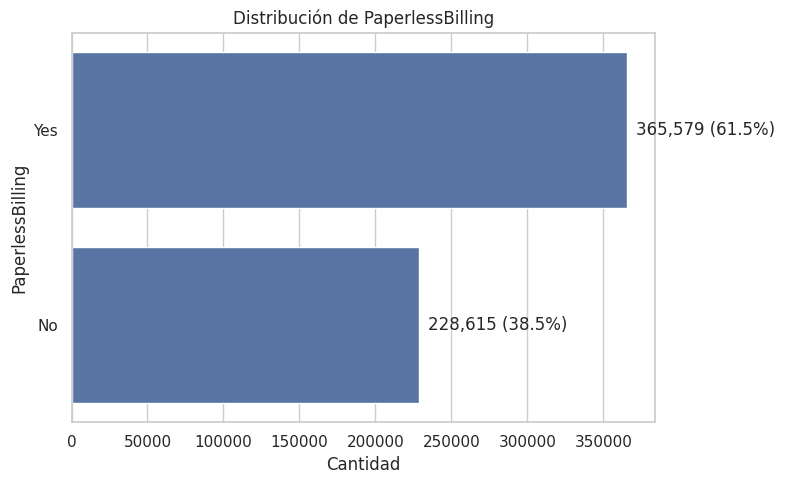

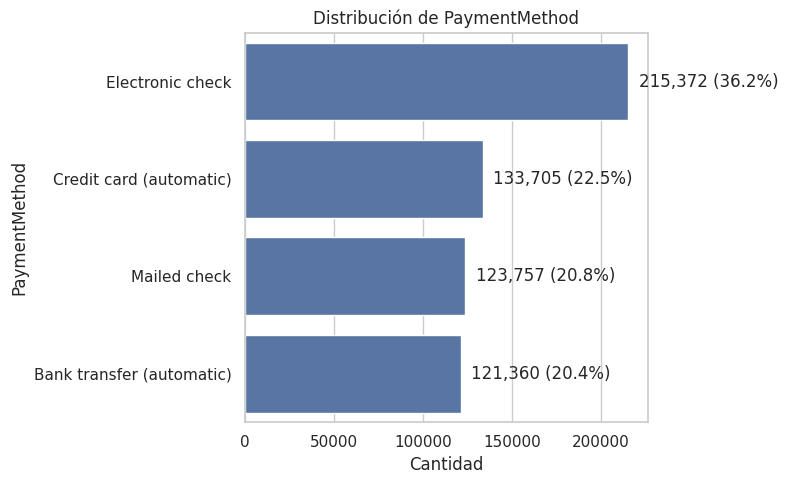

In [13]:
for col in categorical_cols:
    plt.figure(figsize=(8,5))

    # Conteo
    counts = df[col].value_counts()
    total = len(df)

    # Crear barplot horizontal
    ax = sns.barplot(x=counts.values, y=counts.index)

    # Agregar labels con % y count
    for i, v in enumerate(counts.values):
        pct = (v / total) * 100
        ax.text(v + (total * 0.01), i, f'{v:,} ({pct:.1f}%)', va='center')

    plt.title(f'Distribución de {col}')
    plt.xlabel('Cantidad')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Observaciones de Variables Categóricas

* **Churn:** Se observa un fuerte desbalance en las clases, notando que el 22.5% de la población corresponde a clientes que abandonan el servicio brindado.
* **PaymentMethod:** El método de pago con mayor uso es **Electronic Check**, pero la utilización de los otros canales de pago (**Credit Card (automatic)**, **Bank Transfer**, **Mailed Check**) da indicios de que tenemos clientes que pertenecen a una población menos madura.
* **PaperlessBilling:** Más del 60% de los clientes tienen facturación digital. Sería interesante analizar el comportamiento de esta variable frente al **Churn**.
* **Contract:** Más del 50.3% de los clientes utilizan contratación mes a mes, lo que sugiere que son productos de suscripción. También se observa que el 31.5% de la clientela tiene un contrato de 2 años, indicando que podrían ser empresas.
* **StreamingMovies:** Esta variable confirma claramente que es una población relativamente joven. También levanta sospechas el hecho de que el 23.7% no tiene servicio de internet.
* **DeviceProtection:** Este servicio no es muy demandado, solo el 37.7% de la población lo tiene, mientras que el 23.7% muestra que no tiene internet.
* **OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, InternetService:** Todas estas variables tienen algo en común que es una constante interesante: el 23.7% de su población no tiene suscrito el servicio de internet. Esto da a entender que existe una parte de la población que carece del servicio base, o bien, es una población madura que no presenta necesidad de este.
* **PhoneService:** El 94% de la población presenta servicio de teléfono.
* **gender:** La distribución entre géneros es normal y balanceada.
* **MultipleLines:** Más del 46% de los clientes poseen múltiples líneas de servicio contratado. Sería bueno analizar esta distribución con respecto a **Churn**.

# Analisis bivariado.

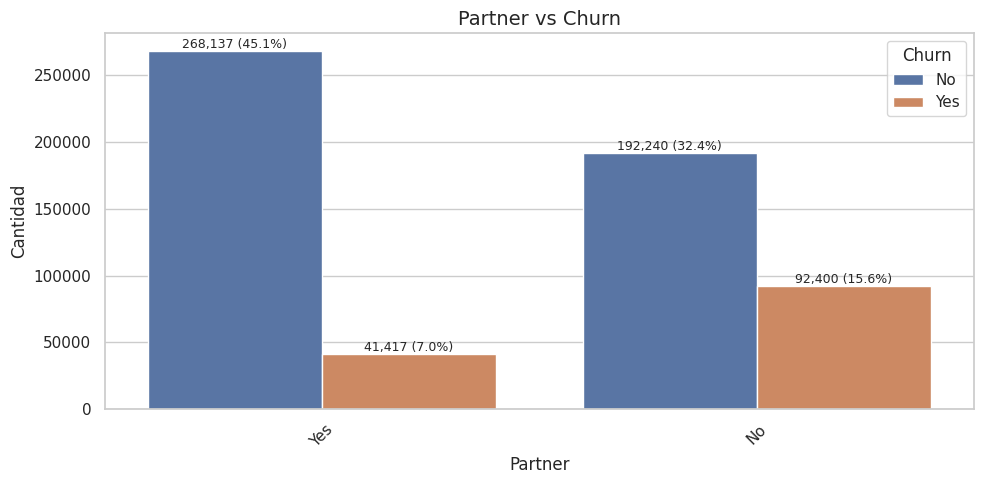

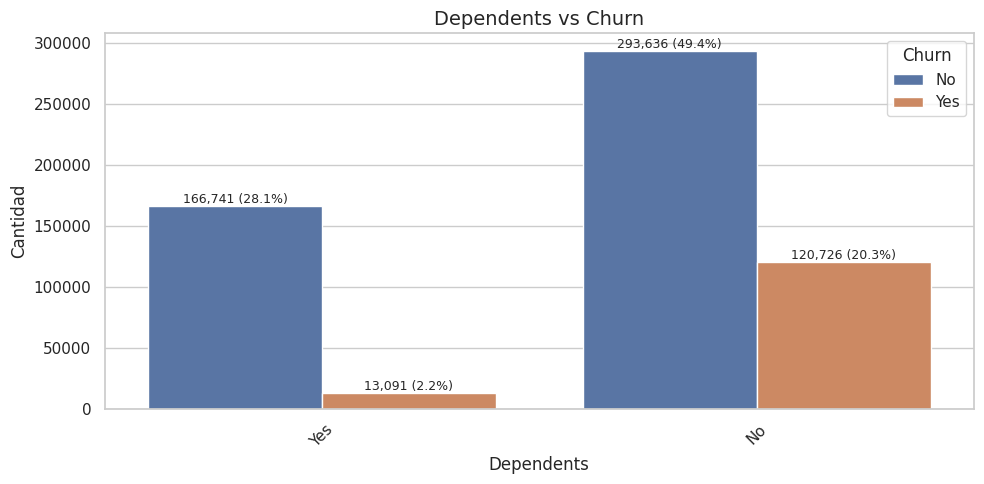

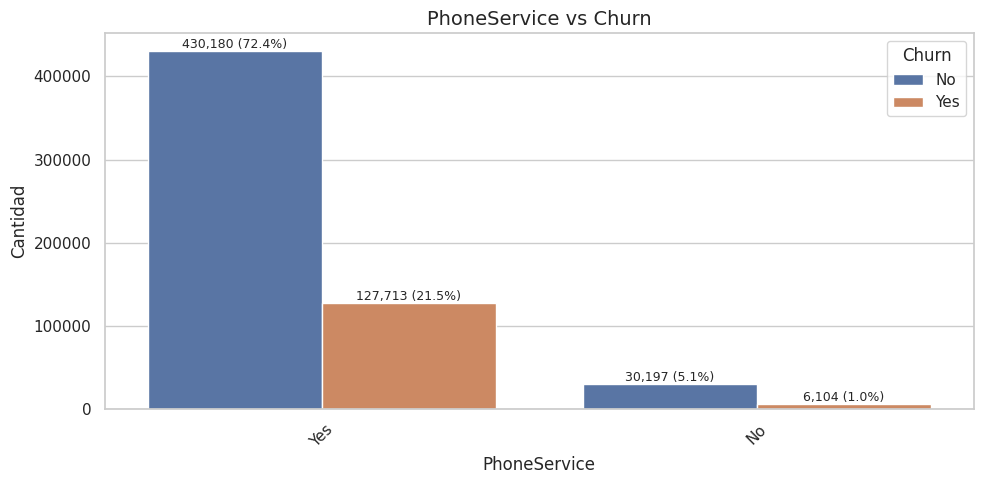

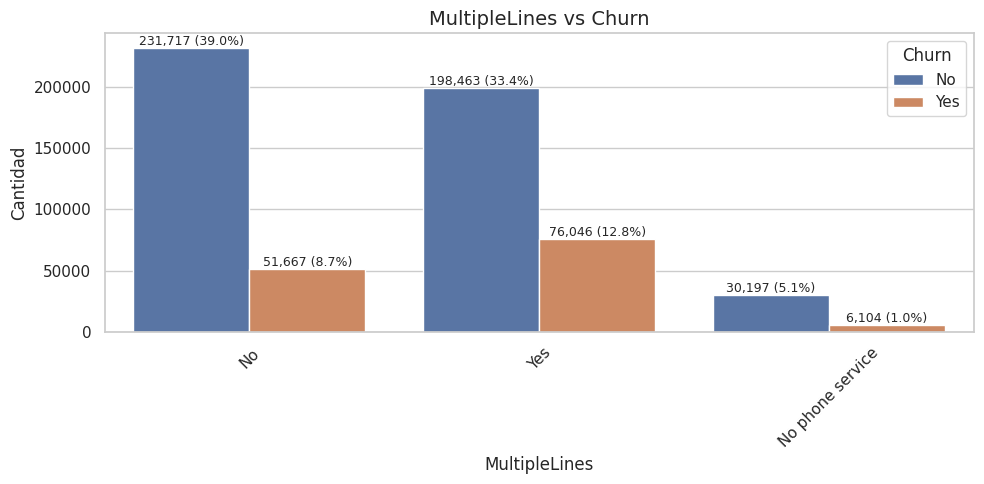

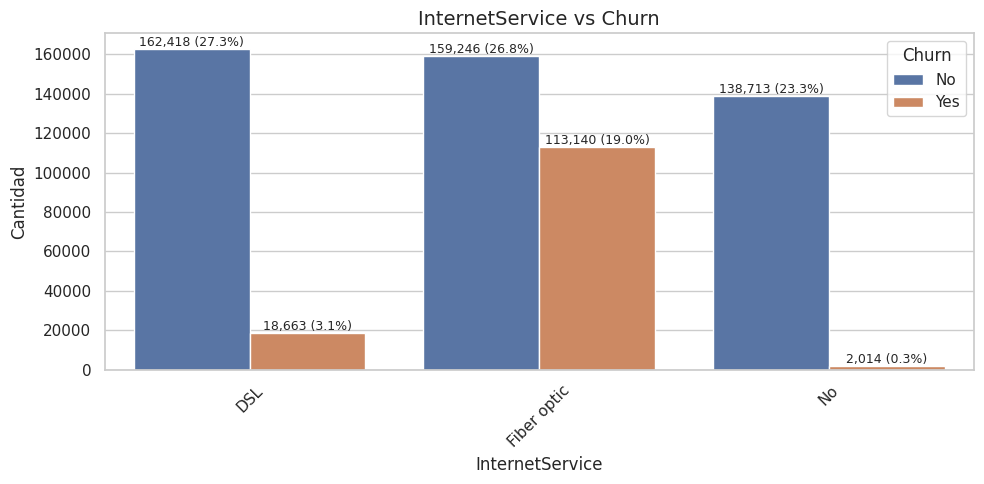

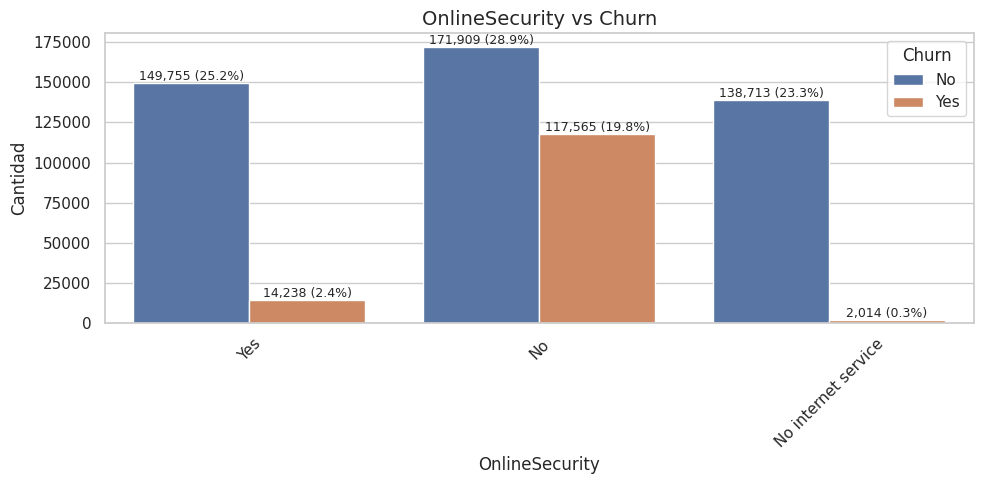

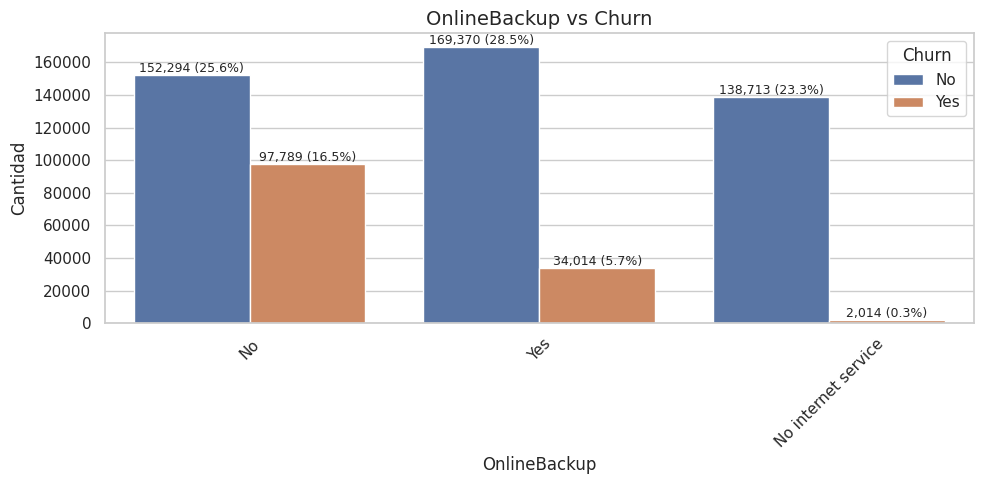

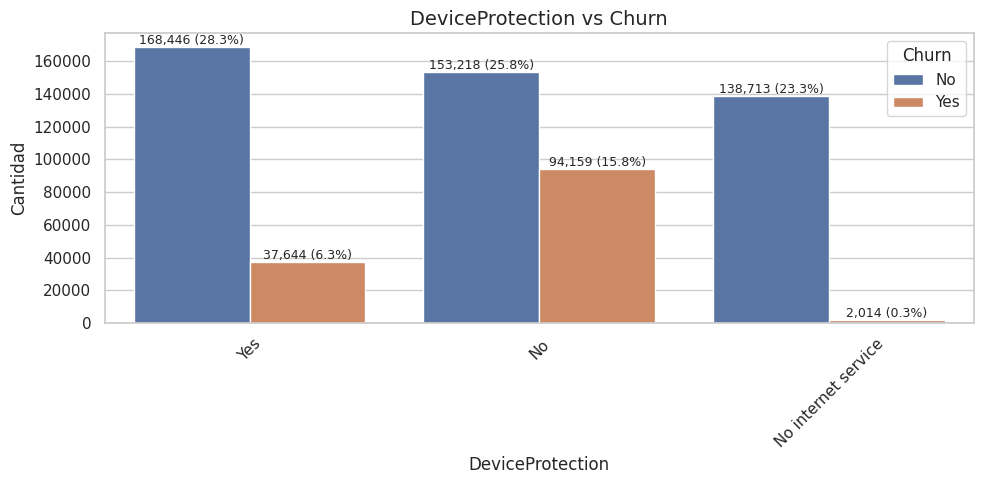

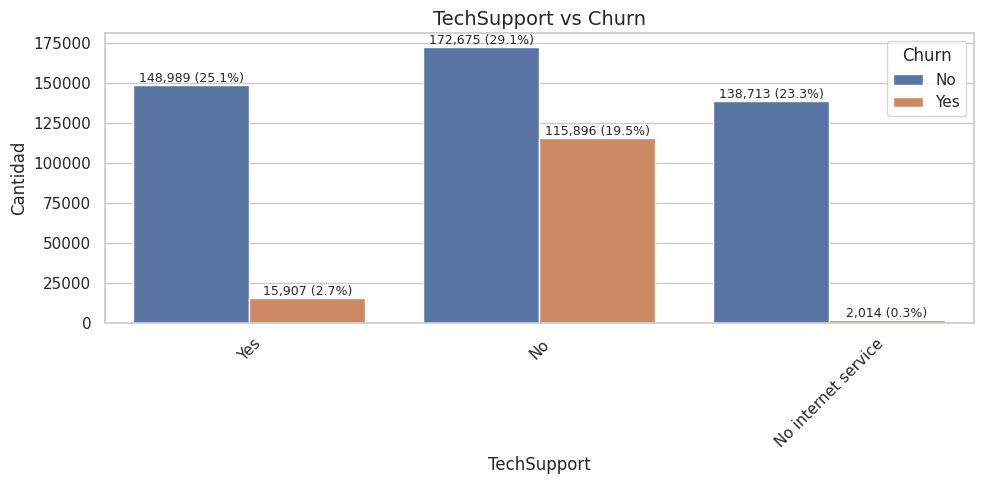

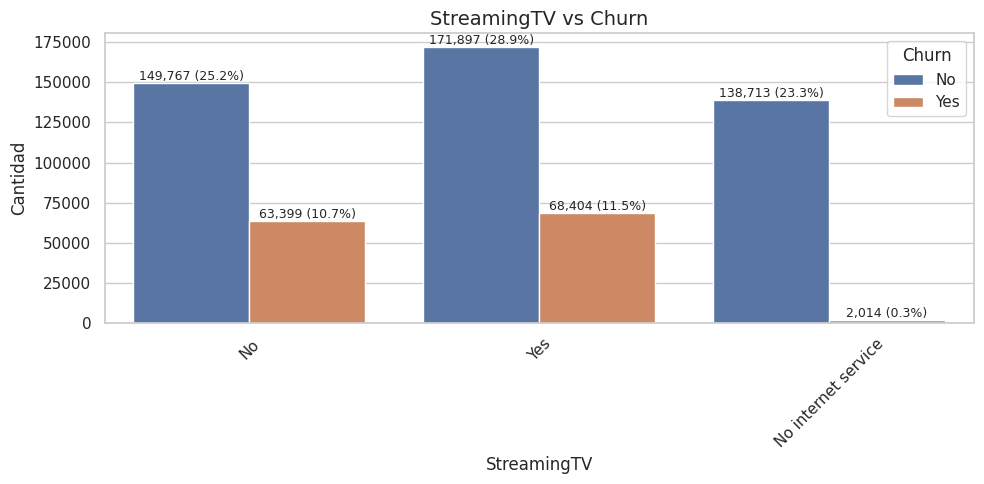

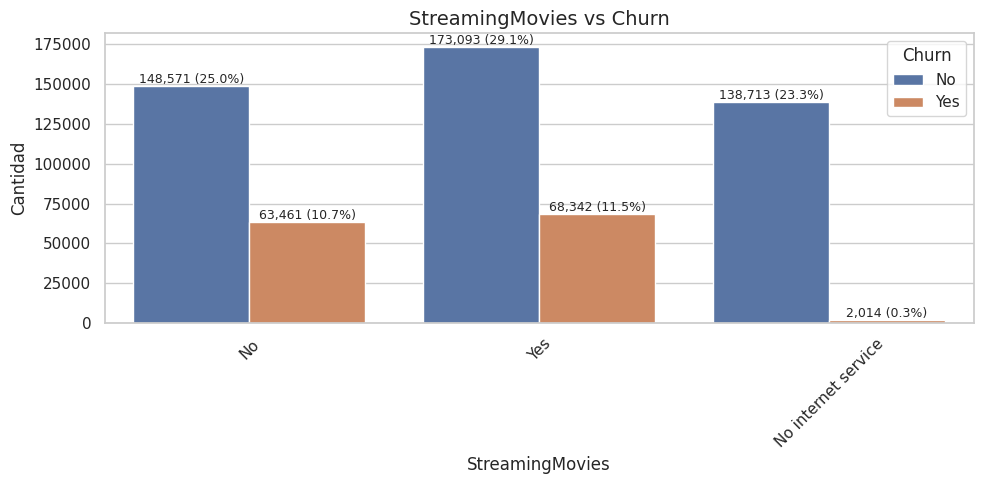

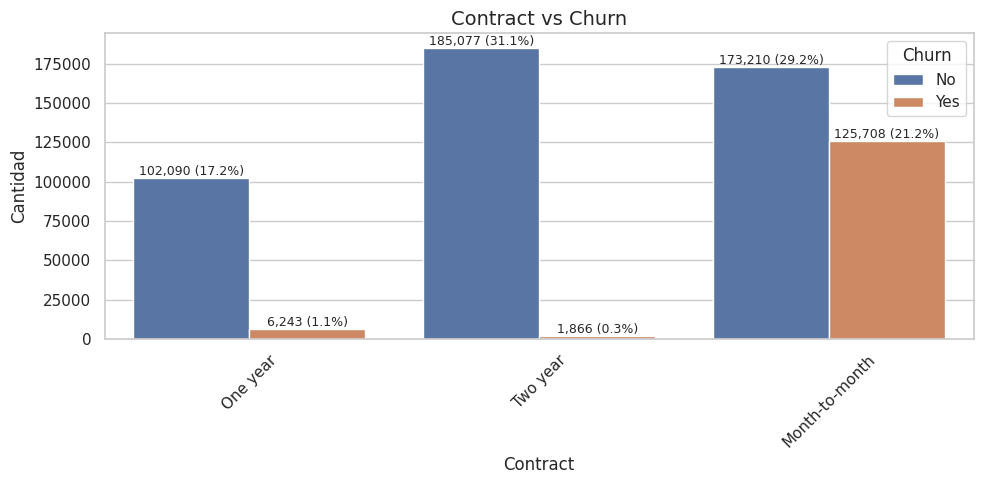

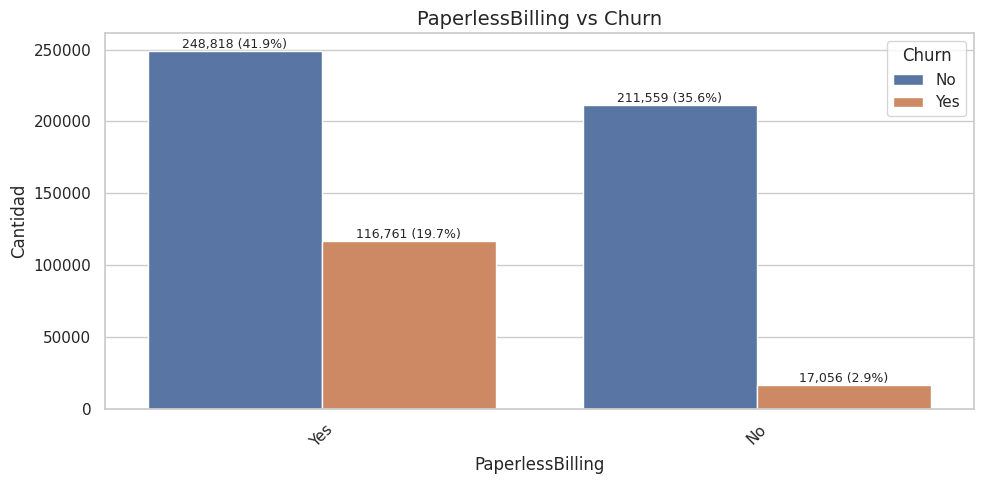

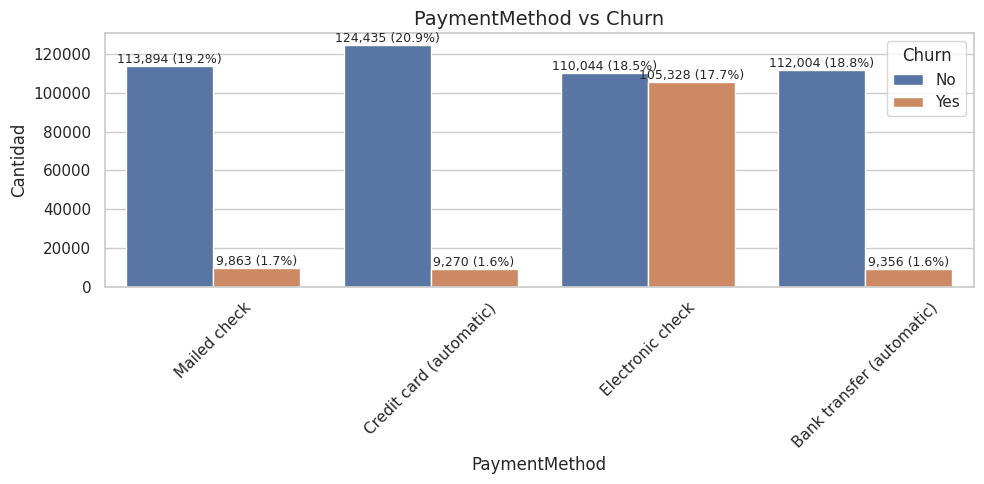

In [14]:
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    ax = sns.countplot(x=col, hue='Churn', data=df)
    total = len(df)

    # recorrer cada grupo de barras
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if height == 0:
                continue
            pct = (height / total) * 100
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f'{int(height):,} ({pct:.1f}%)',
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.title(f'{col} vs Churn', fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel('Cantidad')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

* **MultiplesLines** indica que las personas con multiples lineas tienen un 13% de probablidad de cancelar el servicio, este comportamiento podria ser dado a saturacion de servicios contratados.

* **InternetService** esta variable me parece bastante interesante al hacer la comparativa con la variable objetivo, mostrando que dentro de la población dada los que tienen el servicio de Fiber Optic son los que tienen mas probabilidad de cancelar el mismo, esto quizas es dado a alguna inconformidad con el servicio siento este el 10% de la población.

* **OnlineSecurity** esta variable Tambien refleja un patron anomalo, el 19.8% de la población tiene alta probabilidad de churn porque no tiene servicio de Seguridad contratado, esto podria referirse a un patron de fraude.

* **PaymentMethod** el grafico confirmo algo que me llama bastante la atención, la gran masa de clientes con probabilidad de churn tienen el método de pago **Electrinic Check** esto representa el 17.7% de la población, luego de esto todos los otros métodos de pago reflejan menos del 1.8% de probabilidad de churn.

* **Contract** al ver esta variable contra churn se confirma que los clientes que pagan mes a mes son los que tienen mayor probabilidad de irse, en cambio los que tienen contratos mas largos tienen menos probabilidad, lo ideal seria ver la posibilidad de realizar contratos mas largos para poder reducir esto.

* **TechSuport & DeviceProtection** son variables muy similares en comportamiento, las mimas reflejan una alta posibilidad de churn en clientes que no cuentan con estos servicios.

* **InternetService** el churn en los clientes con Fibra Optica es bastante alto, representando esto el 19% de la población, vale la pena destacar que este servicio es Premium cuando lo comparamos con el DSL.

* **Dependents** las ciudadanos sin dependientes reflejan el 20.3% de la población churn del dataset.

## Selección del Codificador Categórico

In [15]:

y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn'])

# Columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = X.select_dtypes(exclude=['object']).columns.tolist()

# Train / Test split (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Función KS (la mantengo igual)
def ks_statistic(y_true, y_prob):
    df_ks = pd.DataFrame({'y': y_true, 'prob': y_prob})
    df_ks = df_ks.sort_values('prob')
    df_ks['cum_good'] = (df_ks['y'] == 0).cumsum() / (df_ks['y'] == 0).sum()
    df_ks['cum_bad']  = (df_ks['y'] == 1).cumsum() / (df_ks['y'] == 1).sum()
    return np.max(np.abs(df_ks['cum_good'] - df_ks['cum_bad']))

# ====================== PIPELINES ======================

#  One Hot Encoding + Escalado
ohe_pipe = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])),
    ('model', LogisticRegression(max_iter=1000,class_weight='balanced'))
])

# Target Encoding + Escalado
tg_pipe = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', TargetEncoder(), categorical_cols)
    ])),
    ('model', LogisticRegression(max_iter=1000))
])

#  WOE Encoding
woe_pipe = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', WOEEncoder(), categorical_cols)
    ])),
    ('model', LogisticRegression(max_iter=1000))
])


pipelines = {
    "OHE": ohe_pipe,
    "Target Encoding": tg_pipe,
    "WOE (Librería)": woe_pipe
}

results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)

    results.append({
        'Model': name,
        'AUC': roc_auc_score(y_test, y_prob),
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'KS': ks_statistic(y_test, y_prob)
    })

# Resultados finales
results_df = pd.DataFrame(results).sort_values(by='AUC', ascending=False)
display(results_df)

,Model,AUC,Accuracy,F1,KS
2,WOE (Librería),0.908299,0.854316,0.670887,0.665440
0,OHE,0.908280,0.806225,0.671685,0.664963
1,Target Encoding,0.907981,0.854400,0.671002,0.665986


Se compararon tres técnicas de codificación (OHE, Target Encoding y WOE). El **Weight of Evidence (WoE)** fue el que mejor balance general presentó y, especialmente, destaca por su capacidad de reflejar la relación entre cada categoría y la variable objetivo (*Churn*).

---

## Análisis de Correlaciones, Multicolinealidad y Poder Predictivo (WoE) – Antes del Feature Engineering

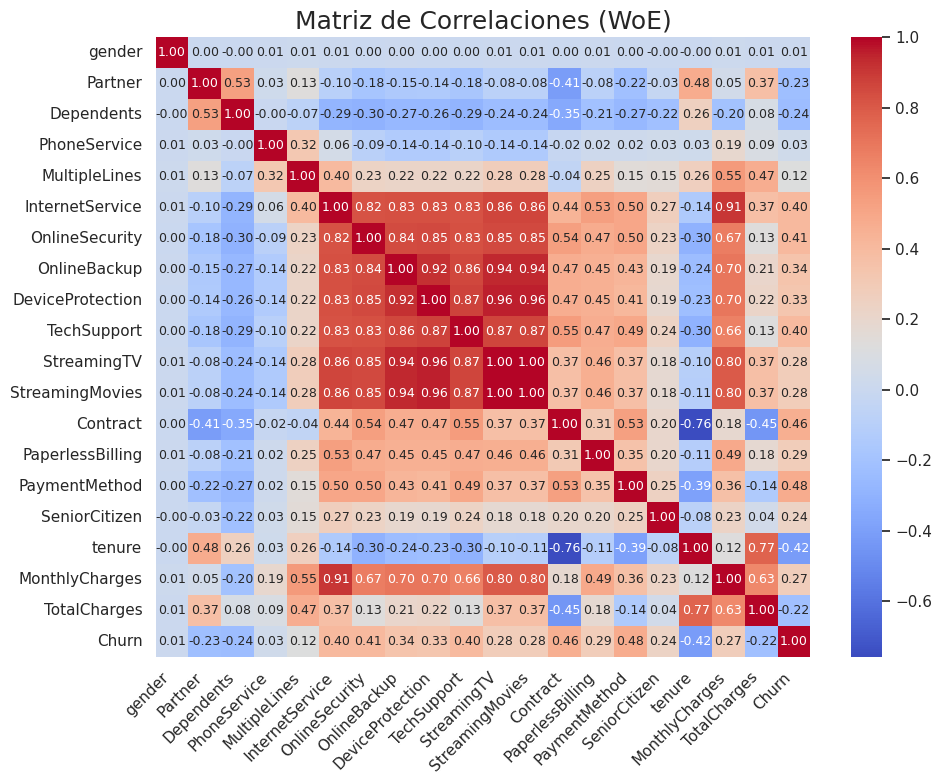

In [16]:
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1}).astype(int)

y = df['Churn']
X = df.drop(columns='Churn')


binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in X.columns and X[col].dtype == 'object':
        X[col] = X[col].map({'Yes': 1, 'No': 0}).astype(int)

# Columnas originales
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

#  Verificación
missing = [col for col in cat_cols + num_cols if col not in X.columns]


#  Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('woe', WOEEncoder(), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop'
)

#  Transformar
X_transformed = preprocessor.fit_transform(X, y)

#  Crear DataFrame
df_en = pd.DataFrame(X_transformed, columns=cat_cols + num_cols)
df_en['Churn'] = y.reset_index(drop=True)

#  Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_en.corr()



sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    annot_kws={"size": 9})



plt.title('Matriz de Correlaciones (WoE)', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Variance Inflation Factor VIF

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


X = df_en.drop(columns=['Churn'])
X = X.select_dtypes(include=['number'])

# Agregamos constante
X = add_constant(X)

# calculo VIF
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

vif_data = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)

print("VIF para todas las variables:")
vif_df = pd.DataFrame(vif_data, columns=['Variable', 'VIF'])
vif_df

VIF para todas las variables:


,Variable,VIF
0,StreamingTV,2498.699874
1,StreamingMovies,2428.364030
2,const,106.778683
3,MonthlyCharges,24.416056
4,InternetService,19.542926
5,DeviceProtection,18.266045
6,OnlineBackup,12.061593
7,TotalCharges,10.467508
8,tenure,7.160645
9,TechSupport,6.781358


## Information Value IV

In [18]:
def calculate_iv(df, target_col='Churn', bins=10):

    iv_dict = {}
    df = df.copy()

    for col in df.columns:
        if col == target_col:
            continue

        # Bines
        if df[col].dtype in ['int64', 'float64']:
            df['bin'] = pd.qcut(df[col], q=bins, duplicates='drop')
        else:
            df['bin'] = df[col]

        # Calcular distribuciones
        grouped = df.groupby('bin', observed=False)[target_col].agg(['count', 'sum'])

        grouped['non_event'] = grouped['count'] - grouped['sum']
        grouped['event_rate'] = grouped['sum'] / grouped['sum'].sum()
        grouped['non_event_rate'] = grouped['non_event'] / grouped['non_event'].sum()

        # Evita Log(0)
        grouped['event_rate'] = grouped['event_rate'].replace(0, 0.0001)
        grouped['non_event_rate'] = grouped['non_event_rate'].replace(0, 0.0001)

        # Calcular WoE e IV
        grouped['woe'] = np.log(grouped['event_rate'] / grouped['non_event_rate'])
        grouped['iv'] = (grouped['event_rate'] - grouped['non_event_rate']) * grouped['woe']

        iv_total = grouped['iv'].sum()
        iv_dict[col] = round(iv_total, 4)

    iv_df = pd.DataFrame.from_dict(iv_dict, orient='index', columns=['IV'])
    iv_df = iv_df.sort_values(by='IV', ascending=False)

    return iv_df


iv_results = calculate_iv(df_en, target_col='Churn', bins=10)
iv_results

,IV
Contract,1.8283
PaymentMethod,1.3523
tenure,1.3069
OnlineSecurity,1.2610
InternetService,1.1674
TechSupport,1.1672
MonthlyCharges,1.0594
OnlineBackup,0.6812
DeviceProtection,0.5786
TotalCharges,0.4242


## Análisis de Correlaciones, Multicolinealidad y Poder Predictivo (WoE) – Antes del Feature Engineering

Tras aplicar la transformación **Weight of Evidence (WoE)** al dataset original, analicé la matriz de correlaciones, el **Variance Inflation Factor (VIF)** y el **Information Value (IV)**.

**Observaciones principales de la matriz de correlación:**

- **Perfil Demográfico:** `Gender` (~0.01) y `SeniorCitizen` (~0.24) muestran poca o moderada relación con *Churn*. `Partner` y `Dependents` tienen correlación moderada (0.53).
- **Servicios y Cargos:** Identifiqué un bloque de alta correlación (0.80–0.96) entre servicios adicionales (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`). `MonthlyCharges` e `InternetService` están muy correlacionados (0.91). `TotalCharges` está fuertemente ligada a `tenure` (0.77).
- **Factores de Riesgo de Abandono:** `PaymentMethod` (Electronic check) presenta la correlación positiva más alta con *Churn* (~0.48), seguido de `Contract` (~ -0.35). `OnlineSecurity` y `TechSupport` muestran correlación negativa (~ -0.30).

**Análisis del VIF:**
Detecté alta multicolinealidad en servicios de streaming (`StreamingTV` ≈ 2499, `StreamingMovies` ≈ 2428). Otras variables con VIF elevado: `MonthlyCharges` (24.42), `InternetService` (19.54) y `TotalCharges` (10.47 / 7.83). Decidí eliminar `TotalCharges` por su VIF cercano al umbral y menor correlación con *Churn* frente a `tenure`.

**Análisis del Information Value (IV):**
- Muy fuerte: `Contract` (1.8283), `PaymentMethod` (1.3523), `tenure` (1.3069), `OnlineSecurity` (1.2610), `InternetService` (1.1674).
- La mayoría de variables demográficas (`gender`, `Partner`, `Dependents`, etc.) tienen **IV = 0.0000**.

**Conclusión:**  
Identifiqué alta redundancia y multicolinealidad en los servicios adicionales, junto con un grupo claro de variables predictivas. Estas observaciones me motivaron a realizar el Feature Engineering para reducir ruido y mejorar la estabilidad de los modelos.

**Nota:** Todas las asociaciones son correlacionales y **no implican causalidad**.

## Feature Engineering: Propuestas de Transformación

### Creación de la Variable `Sag` (Servicios Agregados)
Creé una variable sintética categórica para simplificar la redundancia:

* **`Sag = 1`**: Más de 2 servicios adicionales.
* **`Sag = 0`**: 2 o menos servicios adicionales.


---

## Feature Engineering y Transformaciones

In [19]:

servicio = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


diccionario_mapeo = {
    'Yes': 1,
    'No': 0,
    'No internet service': 0
}

# Sag
df['Sag'] = 0

for i in servicio:
    df[i] = df[i].map(diccionario_mapeo).fillna(0).astype(int)
    df['Sag'] += df[i]

df['Sag'] = (df['Sag'] > 2).astype(int)

# Is_New
df['Is_New'] = (df['tenure'] < 6).astype(int)

# tenure en rangos
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 100],
    labels=['0', '1', '2', '3']
)

# Avg_charges
df['Avg_Charges'] = df['TotalCharges'] / (df['tenure'] + 1)



# Cliente de alto riesgo
df['High_Risk'] = (
    (df['tenure'] < 12) &
    (df['Contract'] == 'Month-to-month') &
    (df['PaymentMethod'] == 'Electronic check')
).astype(int)

# Eliminar las columnas originales que ya fueron transformadas o consolidadas

df.drop(columns=[
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MonthlyCharges', 'tenure', 'Contract', 'PaymentMethod','TotalCharges'
], inplace=True)

Como se mencionó anteriormente, se creó la variable **Sag (Servicios Agregados)**. Esta variable binaria toma el valor de:

- **1**: clientes con más de dos servicios adicionales contratados.
- **0**: clientes con dos o menos servicios adicionales.

Esta transformación permite reducir la dimensionalidad agrupando múltiples variables relacionadas con servicios en una sola característica representativa.

La variable **Is_New** identifica clientes con menos de 6 meses dentro de la empresa. Este grupo representa clientes con mayor probabilidad de churn y sobre los cuales la empresa debería enfocar mayores esfuerzos de retención.

Se creó la variable **tenure_group** para segmentar la variable **tenure**, correspondiente al tiempo de permanencia del cliente en la empresa. Esta agrupación permite al modelo identificar patrones de abandono según el ciclo de vida del cliente.

La variable **Avg_Charges** calcula el promedio de pagos realizados por cliente en función de su permanencia, permitiendo identificar diferencias de comportamiento entre clientes de mayor y menor valor.

Finalmente, la variable **High_Risk** identifica clientes con menos de un año en la empresa, contratos *Month-to-Month* y método de pago *Electronic Check*. Como se observó en el análisis exploratorio, este patrón está asociado a un mayor riesgo de churn.

---

## Análisis de Correlaciones, Multicolinealidad y Poder Predictivo (WoE) – Después del Feature Engineering

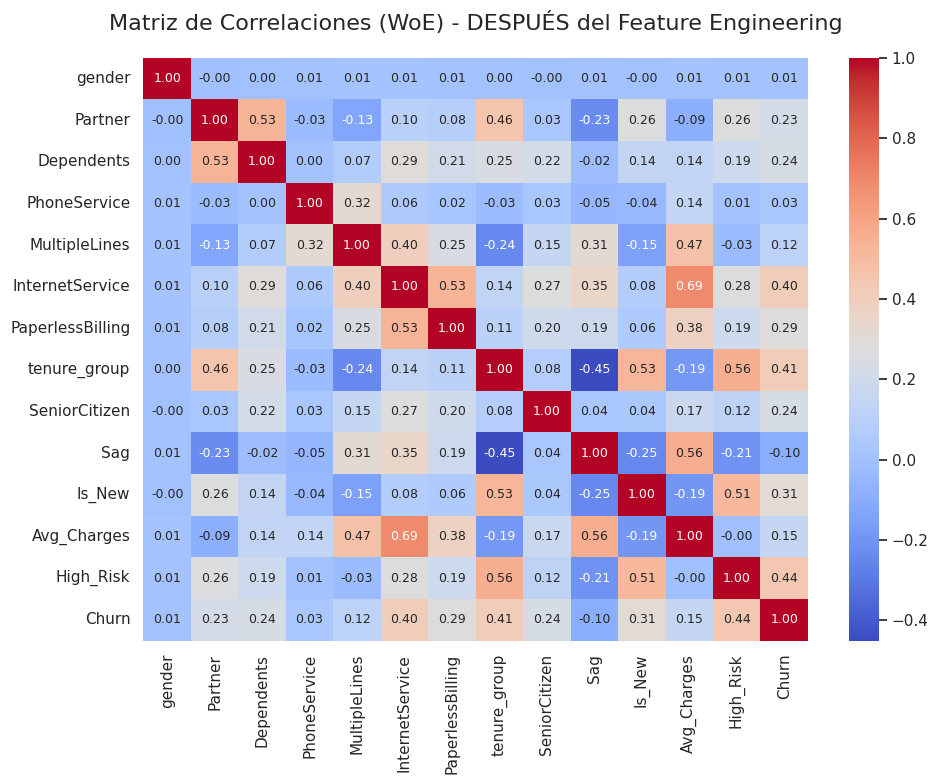

In [20]:

if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1}).astype(int)

y = df['Churn']
X = df.drop(columns=['Churn'])

#  Columnas automáticas
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()


# Preprocesador con WOE (versión correcta)
preprocessor = ColumnTransformer(
    transformers=[
        ('woe', WOEEncoder(regularization=1.0), cat_cols),   # ← Corrección aquí
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop'
)

#  Transformar
X_transformed = preprocessor.fit_transform(X, y)

#  Reconstruir DataFrame
df_en = pd.DataFrame(X_transformed, columns=cat_cols + num_cols)
df_en['Churn'] = y.reset_index(drop=True)

#  Corrección de infinitos (seguridad extra)
df_en = df_en.replace([np.inf, -np.inf], np.nan)
df_en = df_en.fillna(0)

# Matriz de correlación + Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_en.corr()


sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    annot_kws={"size": 9})



plt.title('Matriz de Correlaciones (WoE) - DESPUÉS del Feature Engineering',
          fontsize=16, pad=20)
plt.tight_layout()
plt.show()


# Variance Inflation Factor VIF

In [21]:
X = df_en.drop(columns=['Churn'])
X = X.select_dtypes(include=['number'])

# Agregamos constante
X = add_constant(X)

# calculo VIF para cada Variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

vif_data = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)


print("VIF para todas las variables:")
_vif_df = pd.DataFrame(vif_data, columns=['Variable', 'VIF'])
_vif_df

VIF para todas las variables:


,Variable,VIF
0,const,11.775953
1,InternetService,2.944814
2,Avg_Charges,2.804902
3,tenure_group,2.310291
4,Sag,1.870608
5,High_Risk,1.733078
6,Partner,1.710732
7,Is_New,1.585174
8,Dependents,1.574335
9,MultipleLines,1.544110


## Information Value

In [22]:
iv_results = calculate_iv(df_en, target_col='Churn', bins=10)
iv_results

,IV
InternetService,1.1674
tenure_group,0.9486
Avg_Charges,0.6585
MultipleLines,0.0758
gender,0.0000
PhoneService,0.0000
Dependents,0.0000
Partner,0.0000
PaperlessBilling,0.0000
SeniorCitizen,0.0000


## Análisis de Correlaciones, Multicolinealidad y Poder Predictivo (WoE) – Después del Feature Engineering

Tras aplicar la transformación **Weight of Evidence (WoE)** y las transformaciones de Feature Engineering, analicé la matriz de correlaciones, el **Variance Inflation Factor (VIF)** y el **Information Value (IV)**.

**Observaciones principales de la matriz de correlación:**
- Las variables más fuertemente asociadas al abandono son `High_Risk` (~0.44) y `tenure_group` (~0.41).
- `InternetService` presenta una correlación relevante (~0.40).
- `Is_New` (~0.31) y `PaperlessBilling` (~0.29) también aportan valor predictivo.
- Persiste una correlación alta entre `InternetService` y `Avg_Charges` (~0.69).
- Variables como `gender` (~0.01) y `PhoneService` (~0.03) muestran correlaciones prácticamente nulas con *Churn*.

**Análisis del VIF:**
Ninguna variable supera el umbral crítico de multicolinealidad (VIF ≥ 8). Los valores más altos son `InternetService` (2.94), `Avg_Charges` (2.80) y `tenure_group` (2.31). Las variables sintéticas presentan excelentes niveles (`Sag` = 1.87, `High_Risk` = 1.73).

**Análisis del Information Value (IV):**
- Muy fuerte: `InternetService` (1.1674) y `tenure_group` (0.9486).
- Medio: `Avg_Charges` (0.6585).
- Muy bajo o nulo: `Sag`, `Is_New`, `High_Risk` y la mayoría de variables demográficas tienen **IV = 0.0000**.

**Conclusión:**  
Logré reducir significativamente la multicolinealidad y crear variables sintéticas útiles. El dataset se encuentra en excelentes condiciones para continuar con el modelado y la optimización de hiperparámetros.




---

## Modelado Baseline

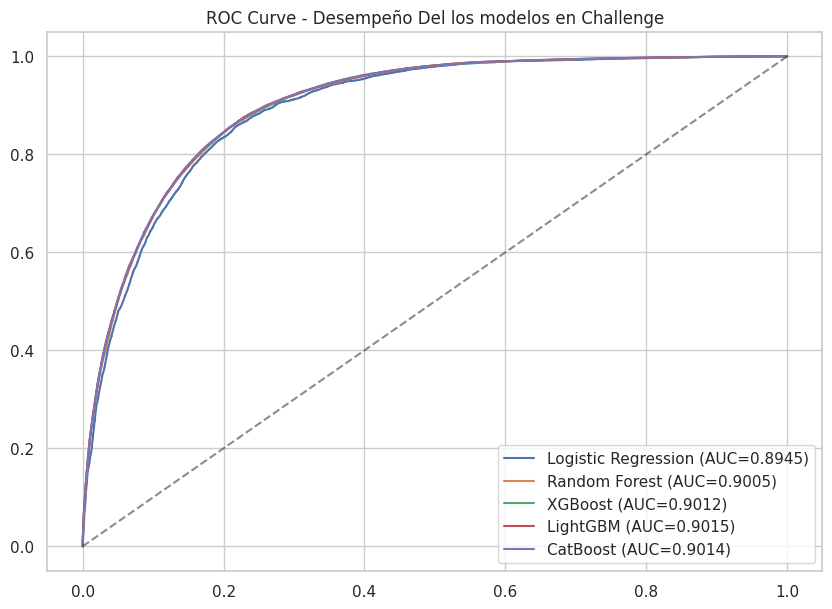

,Model,AUC Train,AUC Test,Diff,KS Test
3,LightGBM,0.9018,0.9015,0.0003,0.6472
4,CatBoost,0.9054,0.9014,0.0040,0.6470
2,XGBoost,0.9049,0.9012,0.0037,0.6466
1,Random Forest,0.9021,0.9005,0.0017,0.6461
0,Logistic Regression,0.8932,0.8945,-0.0013,0.6395


In [23]:
from sklearn import set_config
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, roc_curve

set_config(transform_output="pandas")

df_model = df.copy(deep=True)
y = df_model['Churn'].map({'No': 0, 'Yes': 1}) if df_model['Churn'].dtype == 'object' else df_model['Churn']
X = df_model.drop('Churn', axis=1)

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# PreProcesadores
preprocessor = ColumnTransformer(
    transformers=[
        ('woe_enc', WOEEncoder(), cat_cols),
        ('keep_num', 'passthrough', num_cols)
    ]
)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_test, X_out, y_test, y_out = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=555)

# Modeos Del Challenge
r_st = 555
models = {
    "Logistic Regression": Pipeline([
        ("pre", preprocessor),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=r_st,class_weight='balanced'))
    ]),
    "Random Forest": Pipeline([
        ("pre", preprocessor),
        ("model", RandomForestClassifier(max_depth=10, random_state=r_st))
    ]),
    "XGBoost": Pipeline([
        ("pre", preprocessor),
        ("model", XGBClassifier(random_state=r_st, eval_metric='logloss'))
    ]),
    "LightGBM": Pipeline([
        ("pre", preprocessor),
        ("model", LGBMClassifier(random_state=r_st, verbosity=-1))
    ]),
    "CatBoost": Pipeline([
        ("pre", preprocessor),
        ("model", CatBoostClassifier(random_state=r_st, verbose=0))
    ])
}

# Entrenamiento y Evaluación
results = []
plt.figure(figsize=(10, 7))

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_probs = model.predict_proba(X_train)[:, 1]
    y_test_probs = model.predict_proba(X_test)[:, 1]

    auc_train = roc_auc_score(y_train, y_train_probs)
    auc_test = roc_auc_score(y_test, y_test_probs)

    # KS
    fpr, tpr, _ = roc_curve(y_test, y_test_probs)
    ks_test = max(tpr - fpr)

    results.append({
        "Model": name,
        "AUC Train": round(auc_train, 4),
        "AUC Test": round(auc_test, 4),
        "Diff": round(auc_train - auc_test, 4),
        "KS Test": round(ks_test, 4)
    })

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_test:.4f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title("ROC Curve - Desempeño Del los modelos en Challenge")
plt.legend()
plt.show()


results_df = pd.DataFrame(results).sort_values("AUC Test", ascending=False)
display(results_df)

Se entrenaron cinco modelos utilizando el pipeline con **WOEEncoder**. Los modelos de boosting (CatBoost, LightGBM y XGBoost) fueron claramente superiores, alcanzando un AUC en test superior a **0.916**.

## Busqueda de HiperParametros con Optuna.

In [26]:
import numpy as np
import optuna
!pip install optuna-integration[xgboost]
from optuna.integration.xgboost import XGBoostPruningCallback
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

def objective(trial):
    max_d = trial.suggest_int("max_depth", 3, 8)
    max_leaves_limit = min(255, 2**max_d)

    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 1200),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "max_depth":         max_d,
        "grow_policy":       "lossguide",
        "max_leaves":        trial.suggest_int("max_leaves", 8, max_leaves_limit),
        "subsample":         trial.suggest_float("subsample", 0.4, 0.9),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.4, 0.9),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 30),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 6, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 6, log=True),
        "gamma":             trial.suggest_float("gamma", 1e-3, 5, log=True),

        "random_state":      42,
        "device":            "cuda", # Cambiar a "cpu" si no hay GPU disponible
        "tree_method":       "hist",
        "eval_metric":       "auc",
        "verbosity":         1
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=555)
    auc_val_list   = []
    auc_train_list = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # ====================================================================
        # CORRECCIÓN 1: Preprocesamiento manual por Fold (Evita data leakage)
        # ====================================================================
        X_tr_prep = preprocessor.fit_transform(X_tr, y_tr)
        X_val_prep = preprocessor.transform(X_val)

        # CORRECCIÓN 2: El callback se asocia a la evaluación interna del modelo.
        # Captura el comportamiento árbol por árbol en el fold actual.
        pruning_callback = XGBoostPruningCallback(trial, "validation_0-auc")

        model = XGBClassifier(**params, callbacks=[pruning_callback])

        # Entrenar pasando los datos correctamente transformados
        model.fit(
            X_tr_prep, y_tr,
            eval_set=[(X_val_prep, y_val)],
            verbose=False
        )

        # Evaluación con los datasets transformados
        val_preds = model.predict_proba(X_val_prep)[:, 1]
        auc_v = roc_auc_score(y_val, val_preds)
        auc_val_list.append(auc_v)

        train_preds = model.predict_proba(X_tr_prep)[:, 1]
        auc_t = roc_auc_score(y_tr, train_preds)
        auc_train_list.append(auc_t)

    # Métricas consolidadas tras evaluar todos los folds
    auc_val_mean   = np.mean(auc_val_list)
    auc_train_mean = np.mean(auc_train_list)

    diff = abs(auc_train_mean - auc_val_mean)
    penalty = 0
    if diff > 0.02:
        penalty = diff * 1.9

    # Almacenar atributos extendidos en el histórico de Optuna
    trial.set_user_attr("auc_train", round(auc_train_mean, 5))
    trial.set_user_attr("overfit_diff", round(diff, 5))

    return auc_val_mean - penalty

# ====================== EJECUCIÓN MODIFICADA ======================
semilla_optuna = optuna.samplers.TPESampler(seed=42)

# Modificamos el pruner para que sea compatible con las épocas que reporta XGBoost natively
study = optuna.create_study(
    direction="maximize",
    sampler=semilla_optuna,
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=15)
)

# Ejecución
study.optimize(objective, n_trials=100, show_progress_bar=False)

results_df = study.trials_dataframe()
print("¡Optimización Completa!")

Streaming output truncated to the last 5000 lines.
  self._trial.report(current_score, step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/xgboost/xgboost.py:76: UserWarning: The reported value is ignored because this `step` 585 is already reported.
  self._trial.report(current_score, step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/xgboost/xgboost.py:76: UserWarning: The reported value is ignored because this `step` 586 is already reported.
  self._trial.report(current_score, step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/xgboost/xgboost.py:76: UserWarning: The reported value is ignored because this `step` 587 is already reported.
  self._trial.report(current_score, step=epoch)
/usr/local/lib/python3.12/dist-packages/optuna_integration/xgboost/xgboost.py:76: UserWarning: The reported value is ignored because this `step` 588 is already reported.
  self._trial.report(current_score, step=epoch)
/usr/local/lib/python3.12/dis

KeyboardInterrupt: 

In [ ]:
print("AUC Test:", roc_auc_score(y_test, y_test_probs))

In [ ]:
from sklearn.pipeline import Pipeline
from scipy.stats import ks_2samp


def calculate_ks(y_true, y_probs):
    df = pd.DataFrame({'target': y_true, 'prob': y_probs})
    buenos = df[df['target'] == 0]['prob']
    malos = df[df['target'] == 1]['prob']
    ks_stat, _ = ks_2samp(buenos, malos)
    return ks_stat


best_params = study.best_params

# XGBoost
final_pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        **best_params,
        device="cuda",
        tree_method="hist",
        random_state=555,
        verbosity=0,
        eval_metric="auc"
    ))
])

#ENTRENAMIENTO FINAL
final_pipeline_xgb.fit(X_train, y_train)

y_train_probs = final_pipeline_xgb.predict_proba(X_train)[:, 1]
y_test_probs  = final_pipeline_xgb.predict_proba(X_test)[:, 1]
y_out_probs   = final_pipeline_xgb.predict_proba(X_out)[:, 1]

# MÉTRICAS
auc_train = roc_auc_score(y_train, y_train_probs)
auc_test  = roc_auc_score(y_test,  y_test_probs)
auc_out   = roc_auc_score(y_out,   y_out_probs)

ks_train = calculate_ks(y_train, y_train_probs)
ks_test  = calculate_ks(y_test,  y_test_probs)
ks_out   = calculate_ks(y_out,   y_out_probs)

diff = auc_train - auc_test



results.append({
    "Model":     "XGBoost + Optuna",
    "AUC Train": auc_train,
    "AUC Test":  auc_test,
    "AUC Out":   auc_out,
    "KS Train":  ks_train,
    "KS Test":   ks_test,
    "KS Out":    ks_out,
    "Diff":      diff
})

results_df_model = pd.DataFrame(results)
results_df_model